# QC Checks

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import ee
import geemap

from identify_locations import identify_forests, identify_route_buffer

ee.Initialize(project='turnkey-lacing-391919')

ma_forest    = identify_forests()
route_buffer = identify_route_buffer()

QC_YEAR  = 2024
QC_DIR   = './qc_outputs'
os.makedirs(QC_DIR, exist_ok=True)

## Export HLS bands for all forest pixels (Jul–Dec 2024)

Uses the median composite across the season. Exports one band at a time to stay under the 50 MB download limit.

In [7]:
hls_median = (
    ee.ImageCollection('NASA/HLS/HLSL30/v002')
    .filterBounds(route_buffer)
    .filterDate(f'{QC_YEAR}-07-01', f'{QC_YEAR}-12-31')
    .select(['B2', 'B4', 'B5'])
    .median()
    .updateMask(ma_forest)
)

# Export one band at a time (~20 MB each, under the 50 MB limit)
band_arrays = {}
for band in ['B2', 'B4', 'B5']:
    path = os.path.join(QC_DIR, f'{band}_{QC_YEAR}.tif')
    if not os.path.exists(path):
        print(f'Exporting {band}...')
        geemap.ee_export_image(
            hls_median.select(band),
            filename=path,
            scale=30,
            region=route_buffer,
            file_per_band=False
        )
    else:
        print(f'Loading cached {band}')

    with rasterio.open(path) as src:
        data   = src.read(1).astype(float)
        nodata = src.nodata
        if nodata is not None:
            data[data == nodata] = np.nan
        band_arrays[band] = data

# Build a flat DataFrame of all valid (non-NaN) forest pixels
mask = np.isfinite(band_arrays['B2'])   # any band works; all share the same forest mask
df   = pd.DataFrame({
    'B2': band_arrays['B2'][mask],
    'B4': band_arrays['B4'][mask],
    'B5': band_arrays['B5'][mask],
})

print(f'\nTotal forest pixels: {len(df):,}')
df.describe()

Loading cached B2
Loading cached B4
Loading cached B5

Total forest pixels: 2,975,012


,B2,B4,B5
count,2.975012e+06,2.975012e+06,2.975012e+06
mean,3.034231e-02,5.783736e-02,3.521946e-01
std,1.182838e-02,2.178637e-02,6.232969e-02
min,-4.142857e-03,3.269444e-03,-1.000000e-02
25%,2.365000e-02,4.275000e-02,3.192500e-01
50%,2.795000e-02,5.520000e-02,3.550000e-01
75%,3.478333e-02,6.980000e-02,3.903500e-01
max,6.132000e-01,7.232000e-01,8.048500e-01


## Check 1: All band values are positive

In [8]:
for band in ['B2', 'B4', 'B5']:
    n_total    = df[band].notna().sum()
    n_negative = (df[band] <= 0).sum()
    pct        = 100 * n_negative / n_total
    status     = 'PASS' if n_negative == 0 else 'FAIL'
    print(f'[{status}] {band}: {n_negative:,} / {n_total:,} values <= 0  ({pct:.2f}%)')

[FAIL] B2: 7 / 2,975,012 values <= 0  (0.00%)
[PASS] B4: 0 / 2,975,012 values <= 0  (0.00%)
[FAIL] B5: 3 / 2,975,012 values <= 0  (0.00%)


## Check 2: Box and whisker plot of band values

/var/folders/b4/_9btyskx4zggvkvbjg6pw0bw0000gn/T/ipykernel_95819/2071255189.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


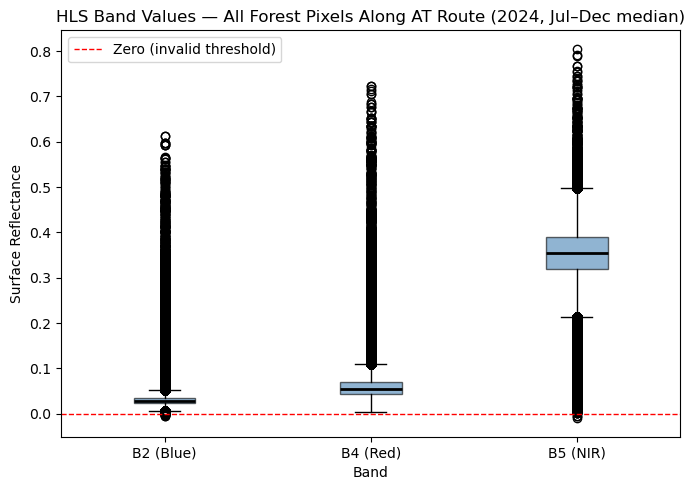

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.boxplot(
    [df['B2'].dropna(), df['B4'].dropna(), df['B5'].dropna()],
    labels=['B2 (Blue)', 'B4 (Red)', 'B5 (NIR)'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='black', linewidth=2)
)

ax.set_title(f'HLS Band Values — All Forest Pixels Along AT Route ({QC_YEAR}, Jul–Dec median)')
ax.set_xlabel('Band')
ax.set_ylabel('Surface Reflectance')
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Zero (invalid threshold)')
ax.legend()

plt.tight_layout()
plt.show()

## Check 3: Pixel-date combinations with any negative band value

In [14]:
import datetime
print("Done importing datetime")
# Load the full per-image collection (not median)
hls_collection = (
    ee.ImageCollection('NASA/HLS/HLSL30/v002')
    .filterBounds(route_buffer)
    .filterDate(f'{QC_YEAR}-07-01', f'{QC_YEAR}-12-31')
    .select(['B2', 'B4', 'B5'])
    .sort('system:time_start')
)
print("Done loading collection")
n_images   = hls_collection.size().getInfo()
print("Done getting image information")
image_list = hls_collection.toList(n_images)
print("Done getting image list")
timestamps = hls_collection.aggregate_array('system:time_start').getInfo()

print(f'Checking {n_images} images for negative band values...\n')

negative_records = []

for i in range(n_images):
    img  = ee.Image(image_list.get(i)).updateMask(ma_forest)
    date = datetime.datetime.utcfromtimestamp(timestamps[i] / 1000).strftime('%Y-%m-%d')

    # Server-side: mask to only pixels where any band is negative
    any_negative = (
        img.select('B2').lt(0)
        .Or(img.select('B4').lt(0))
        .Or(img.select('B5').lt(0))
    )
    negative_pixels = img.updateMask(any_negative).addBands(ee.Image.pixelLonLat())

    # Sample — should be tiny if negatives are rare
    samples  = negative_pixels.sample(region=route_buffer, scale=30, geometries=False)
    count    = samples.size().getInfo()

    print(f'  [{i+1}/{n_images}] {date}: {count} negative pixel(s)')

    if count > 0:
        features = samples.getInfo()['features']
        for f in features:
            p = f['properties']
            negative_records.append({
                'date':      date,
                'longitude': round(p['longitude'], 6),
                'latitude':  round(p['latitude'],  6),
                'B2':        p['B2'],
                'B4':        p['B4'],
                'B5':        p['B5'],
            })

print(f'\nDone. Total pixel-date combinations with negative values: {len(negative_records)}')

if negative_records:
    df_negative = pd.DataFrame(negative_records)[['date', 'latitude', 'longitude', 'B2', 'B4', 'B5']]
    display(df_negative)
else:
    print('No negative values found — all pixels PASS.')

Done importing datetime
Done loading collection
Done getting image information
Done getting image list
Checking 82 images for negative band values...

  [1/82] 2024-07-02: 137 negative pixel(s)
  [2/82] 2024-07-02: 115 negative pixel(s)
  [3/82] 2024-07-09: 0 negative pixel(s)
  [4/82] 2024-07-09: 26 negative pixel(s)
  [5/82] 2024-07-10: 473 negative pixel(s)
  [6/82] 2024-07-10: 83 negative pixel(s)
  [7/82] 2024-07-17: 83 negative pixel(s)
  [8/82] 2024-07-17: 254 negative pixel(s)
  [9/82] 2024-07-18: 5 negative pixel(s)
  [10/82] 2024-07-18: 5 negative pixel(s)
  [11/82] 2024-07-25: 189 negative pixel(s)
  [12/82] 2024-07-25: 312 negative pixel(s)
  [13/82] 2024-07-26: 1 negative pixel(s)
  [14/82] 2024-07-26: 1 negative pixel(s)
  [15/82] 2024-08-02: 285 negative pixel(s)
  [16/82] 2024-08-02: 0 negative pixel(s)
  [17/82] 2024-08-03: 0 negative pixel(s)
  [18/82] 2024-08-03: 0 negative pixel(s)
  [19/82] 2024-08-10: 291 negative pixel(s)
  [20/82] 2024-08-10: 104 negative pixel(

,date,latitude,longitude,B2,B4,B5
0,2024-07-02,42.435583,-73.157424,-0.0006,0.0143,0.4810
1,2024-07-02,42.435319,-73.157797,-0.0240,0.0046,0.5292
2,2024-07-02,42.435049,-73.157805,-0.0007,0.0101,0.5299
3,2024-07-02,42.434767,-73.157084,-0.0207,0.0134,0.5343
4,2024-07-02,42.434497,-73.157092,-0.0031,0.0079,0.5270
...,...,...,...,...,...,...
15685,2024-12-25,42.350250,-73.159920,-0.0309,0.0186,0.1666
15686,2024-12-25,42.349986,-73.160292,-0.0258,0.0336,0.1847
15687,2024-12-25,42.349980,-73.159927,-0.0369,0.0209,0.1827
15688,2024-12-25,42.349716,-73.160299,-0.0115,0.0354,0.1859


## Check 4: Density distribution of negative band values

Percentage of negative pixel-date values per band:
  B2 (Blue): 15,384 / 15,690 (98.0%)
  B4 (Red): 4,980 / 15,690 (31.7%)
  B5 (NIR): 222 / 15,690 (1.4%)



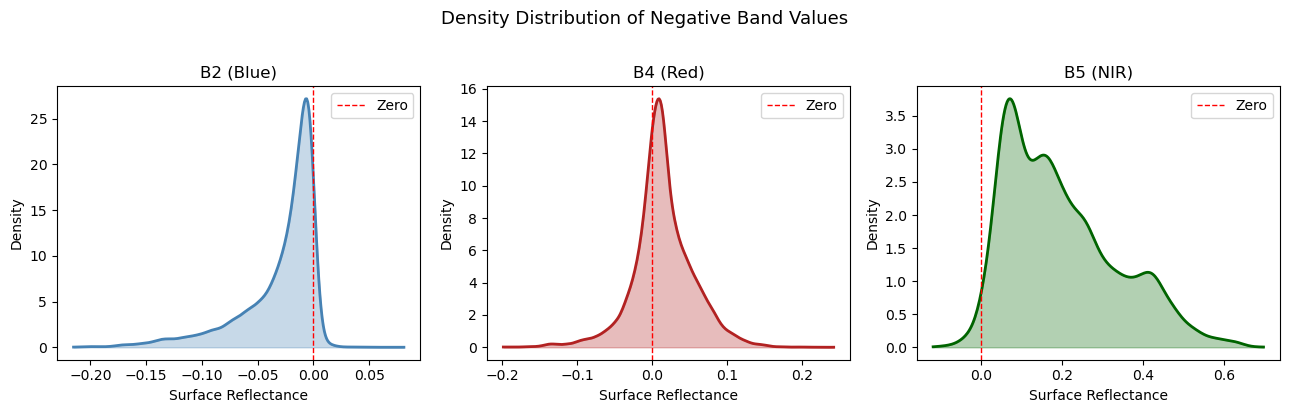

In [16]:
if negative_records:
    from scipy.stats import gaussian_kde

    band_labels = {'B2': 'B2 (Blue)', 'B4': 'B4 (Red)', 'B5': 'B5 (NIR)'}
    colors      = {'B2': 'steelblue', 'B4': 'firebrick', 'B5': 'darkgreen'}

    # Print percentage of each band that is negative
    print('Percentage of negative pixel-date values per band:')
    for band in ['B2', 'B4', 'B5']:
        n_negative = (df_negative[band] < 0).sum()
        n_total    = df_negative[band].notna().sum()
        pct        = 100 * n_negative / n_total if n_total > 0 else 0
        print(f'  {band_labels[band]}: {n_negative:,} / {n_total:,} ({pct:.1f}%)')

    print()

    fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)

    for ax, band in zip(axes, ['B2', 'B4', 'B5']):
        values = df_negative[band].dropna().values

        if len(values) >= 2:
            kde = gaussian_kde(values)
            x   = np.linspace(values.min(), values.max(), 300)
            ax.plot(x, kde(x), color=colors[band], linewidth=2)
            ax.fill_between(x, kde(x), alpha=0.3, color=colors[band])
        else:
            ax.text(0.5, 0.5, 'Too few values', ha='center', va='center',
                    transform=ax.transAxes)

        ax.axvline(0, color='red', linestyle='--', linewidth=1, label='Zero')
        ax.set_title(band_labels[band])
        ax.set_xlabel('Surface Reflectance')
        ax.set_ylabel('Density')
        ax.legend()

    fig.suptitle('Density Distribution of Negative Band Values', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('No negative values found — nothing to plot.')
#98% of blue pixels are negative but they are small (all

In [17]:
df_negative.groupby('date').size() 
#more negative values in november and december likely because of snow
#not a consistent spread so likely not a land cover misclassification problem
#not going to correct for now because should get smoothed in curves

date
2024-07-02     252
2024-07-09      26
2024-07-10     556
2024-07-17     337
2024-07-18      10
2024-07-25     501
2024-07-26       2
2024-08-02     285
2024-08-10     395
2024-08-11     336
2024-08-19     733
2024-08-26     355
2024-08-27     212
2024-09-03       3
2024-09-11       2
2024-09-12       1
2024-09-19      41
2024-09-20     228
2024-09-27      18
2024-09-28      44
2024-10-05     269
2024-10-14     338
2024-10-21       2
2024-10-30     826
2024-11-06      83
2024-11-07     884
2024-11-14       3
2024-11-30    2869
2024-12-01    1880
2024-12-09     760
2024-12-17    1089
2024-12-25    2350
dtype: int64

## Check 5: Random sample of 100 greendown curves with transition dates

In [ ]:
from fit_greendown_curves import _fit_pixel, _decreasing_logistic, compute_curve_ci

OUTPUT_DIR = './greendown_outputs'

# Load cached EVI stack and DOYs
evi_stack = np.load(os.path.join(OUTPUT_DIR, f'hls_evi_stack_{QC_YEAR}.npy'))
doys      = np.load(os.path.join(OUTPUT_DIR, f'hls_evi_doys_{QC_YEAR}.npy'))

# Load transition date GeoTIFFs (point estimates and CIs)
transition_arrays = {}
for phase in ('start', 'middle', 'end'):
    for key, suffix in [('point', ''), ('lower', '_ci_lower'), ('upper', '_ci_upper')]:
        path = os.path.join(OUTPUT_DIR, f'greendown_{phase}{suffix}_{QC_YEAR}.tif')
        with rasterio.open(path) as src:
            data = src.read(1).astype(float)
            data[data == src.nodata] = np.nan
            transition_arrays[f'{phase}_{key}'] = data

_, h, w = evi_stack.shape

# Find pixels with valid fitted transitions
valid_mask = np.isfinite(transition_arrays['middle_point'])
valid_rows, valid_cols = np.where(valid_mask)

# Randomly sample 100 pixels
rng        = np.random.default_rng(seed=42)
n_sample   = min(100, len(valid_rows))
sample_idx = rng.choice(len(valid_rows), size=n_sample, replace=False)
sample_rows = valid_rows[sample_idx]
sample_cols = valid_cols[sample_idx]

t_smooth     = np.linspace(doys.min(), doys.max(), 300)
phase_colors = {'start': 'green', 'middle': 'orange', 'end': 'red'}
month_doys   = [183, 213, 244, 274, 305, 335]
month_labels = ['Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, axes = plt.subplots(10, 10, figsize=(20, 20), sharex=True)
axes = axes.flatten()

plot_num = 0
for r, c in zip(sample_rows, sample_cols):
    if plot_num >= n_sample:
        break

    pixel_evi = evi_stack[:, r, c]
    fit = _fit_pixel(doys, pixel_evi)
    if fit is None:
        continue
    popt, pcov = fit

    ax = axes[plot_num]

    # Raw EVI observations
    valid = np.isfinite(pixel_evi) & (pixel_evi > 0)
    ax.scatter(doys[valid], pixel_evi[valid], color='gray', s=6, zorder=1)

    # Fitted logistic with 95% CI shading
    fitted, ci_lower, ci_upper = compute_curve_ci(popt, pcov, t_smooth)
    ax.plot(t_smooth, fitted, color='steelblue', linewidth=1, zorder=2)
    ax.fill_between(t_smooth, ci_lower, ci_upper, color='steelblue', alpha=0.2, zorder=2)

    # 3 transition dates with CI error bars
    for phase in ('start', 'middle', 'end'):
        t_point = transition_arrays[f'{phase}_point'][r, c]
        t_lower = transition_arrays[f'{phase}_lower'][r, c]
        t_upper = transition_arrays[f'{phase}_upper'][r, c]
        evi_val = _decreasing_logistic(t_point, *popt)

        ax.scatter(t_point, evi_val, color=phase_colors[phase], s=20, zorder=4)
        ax.errorbar(t_point, evi_val,
                    xerr=[[t_point - t_lower], [t_upper - t_point]],
                    fmt='none', color=phase_colors[phase], capsize=2,
                    linewidth=0.8, zorder=3)

    ax.set_xticks(month_doys)
    ax.set_xticklabels(month_labels, fontsize=5, rotation=45)
    ax.tick_params(axis='y', labelsize=5)
    ax.set_title(f'px {plot_num + 1}', fontsize=6)

    plot_num += 1

# Hide unused subplots
for i in range(plot_num, len(axes)):
    axes[i].set_visible(False)

# Shared legend
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legend_elements = [
    Line2D([0], [0], color='steelblue', linewidth=1.5, label='Fitted logistic'),
    Patch(facecolor='steelblue', alpha=0.3, label='95% CI (curve)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green',  markersize=6, label='Start'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='orange', markersize=6, label='Middle'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',    markersize=6, label='End'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=5,
           fontsize=9, bbox_to_anchor=(0.5, 0))

fig.suptitle(f'100 Random Greendown Curves with 95% CIs ({QC_YEAR})', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()